# Dataset reconstruction and canonical cache

This notebook reconstructs daily waitlist trajectories from the archived Enrollment Data JSON, manufactures position-level labels, and checks the resulting features for leakage or implausible values. It does **not** train a model.

The archive stores enrolled + waitlisted demand in `enrollmentLogs` while a section is full. We therefore approximate `waitlist = max(demand - capacity, 0)`. The archive contains neither student identities nor admission offers. The target records whether cumulative observed downward queue movement reaches a position before the deadline. It is not verified student advancement: departures behind a position can count, while departures hidden by offsetting arrivals between snapshots can be missed. The proxy can err in either direction.

In [1]:
from __future__ import annotations

import gc
import json
import os
from pathlib import Path
from zoneinfo import ZoneInfo

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import Parallel, delayed

cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    (path for path in (cwd, *cwd.parents) if (path / 'README.md').exists() and (path / 'model').exists()),
    cwd,
)
DATA_ROOT = PROJECT_ROOT / 'data' / 'Enrollment-Data-master'
CACHE_ROOT = PROJECT_ROOT / 'artifacts' / 'feature-search-cache'
CACHE_ROOT.mkdir(parents=True, exist_ok=True)
ROWS_PER_SESSION = 300_000
RANDOM_STATE = 42
CACHE_VERSION = 5
TORONTO = ZoneInfo('America/Toronto')

assert DATA_ROOT.exists(), f'Missing local archive: {DATA_ROOT}'
pd.set_option('display.max_columns', 100)
DATA_ROOT

PosixPath('/student/anfazsha/oracle/data/Enrollment-Data-master')

## 1. Inventory the archive

The current `20269` session is intentionally excluded from labelled training data because its outcomes are incomplete. Summer sessions use the archive's `fall*` and `winter*` timestamp fields for their first and second subsessions.

In [2]:
sessions_manifest = json.loads((DATA_ROOT / 'sessions.json').read_text(encoding='utf-8'))
sessions = pd.DataFrame(sessions_manifest['sessions'])
sessions['is_summer'] = sessions['sessionCode'].str.endswith('5')
sessions['course_files'] = sessions['sessionCode'].map(
    lambda session: len([p for p in (DATA_ROOT / session).glob('*.json') if not p.name.startswith(('AA', 'aa'))])
)
sessions['label_status'] = np.where(sessions['sessionCode'] == sessions_manifest['default'], 'INCOMPLETE — exclude', 'completed')
sessions

,sessionCode,name,is_summer,course_files,label_status
0,20229,Fall-Winter 2022-2023,False,7761,completed
1,20235,Summer 2023,True,1505,completed
2,20239,Fall-Winter 2023-2024,False,8002,completed
3,20245,Summer 2024,True,1524,completed
4,20249,Fall-Winter 2024-2025,False,8148,completed
5,20255,Summer 2025,True,1591,completed
6,20259,Fall-Winter 2025-2026,False,8319,completed
7,20265,Summer 2026,True,1548,completed
8,20269,Fall-Winter 2026-2027,False,8224,INCOMPLETE — exclude


## 2. Schema-aware reconstruction helpers

Capacity changes use the upstream keys `time` and `newCapacity`. Deadlines are selected by campus and course term. We keep each lecture section separate because queues are section-specific.
Unix timestamps are converted to the `America/Toronto` timezone before observations are grouped by calendar day. This prevents late-evening Toronto snapshots from being assigned to the following UTC date.


In [3]:
def read_json(path: Path) -> dict | list:
    return json.loads(path.read_text(encoding='utf-8'))


def campus_faculty(course_code: str) -> str:
    campus_digit = course_code[-2] if len(course_code) >= 2 else '1'
    if campus_digit == '3':
        return 'SCAR'
    if campus_digit == '5':
        return 'ERIN'
    return 'ARTSC'


def deadline_key(course_code: str) -> str:
    return 'winterWaitlistClosed' if course_code.endswith('S') else 'fallWaitlistClosed'


def waitlist_deadline(session: str, course_code: str) -> int:
    bundles = read_json(DATA_ROOT / session / 'AAtcconstants.json')
    faculty = campus_faculty(course_code)
    bundle = next((item for item in bundles if item['faculty'] == faculty), bundles[0])
    return int(bundle['importantTimestamps'][deadline_key(course_code)])


def capacity_at(meeting: dict, timestamp: int) -> int:
    complex_cap = meeting.get('enrollmentCapComplex')
    if not complex_cap:
        return int(meeting['enrollmentCap'])
    capacity = int(complex_cap.get('initialCap', meeting['enrollmentCap']))
    for change in sorted(complex_cap.get('capChanges', []), key=lambda item: item['time']):
        if int(change['time']) <= timestamp:
            capacity = int(change['newCapacity'])
    return capacity


def course_term(course_code: str) -> str:
    return {'F': 'fall', 'S': 'winter', 'Y': 'full_year'}.get(course_code[-1], 'unknown')

In [4]:
def reconstruct_section(course_path: Path, meeting: dict) -> pd.DataFrame:
    course = read_json(course_path)
    session = course_path.parent.name
    deadline = waitlist_deadline(session, course['code'])
    logs = meeting.get('enrollmentLogs', [])
    count = min(len(logs), len(course.get('timeIntervals', [])))
    if count == 0:
        return pd.DataFrame()

    rows = []
    for timestamp, demand in zip(course['timeIntervals'][:count], logs[:count]):
        timestamp = int(timestamp)
        capacity = capacity_at(meeting, timestamp)
        rows.append({
            'session': session,
            'course_code': course['code'],
            'meeting': meeting.get('meetingNumber', 'UNKNOWN'),
            'timestamp': timestamp,
            'observed_at': pd.to_datetime(timestamp, unit='s', utc=True).tz_convert(TORONTO),
            'deadline': deadline,
            'capacity': capacity,
            'demand': int(demand),
            'waitlist': max(int(demand) - capacity, 0),
            'days_to_deadline': max((deadline - timestamp) / 86_400, 0),
            'campus': campus_faculty(course['code']),
            'term': course_term(course['code']),
        })

    frame = pd.DataFrame(rows).sort_values('timestamp')
    frame = frame[frame['timestamp'] <= deadline].copy()
    if frame.empty:
        return frame

    # Sum every visible future decrease at the collector's raw resolution. Later
    # increases represent people joining behind and do not undo earlier advancement.
    frame['observed_waitlist_drop'] = (frame['waitlist'].shift(1) - frame['waitlist']).clip(lower=0).fillna(0)
    frame['observed_drops_to_deadline'] = (
        frame['observed_waitlist_drop'][::-1].cumsum()[::-1] - frame['observed_waitlist_drop']
    )

    # One observation per Toronto calendar day prevents sampling frequency from becoming a feature.
    frame['calendar_day'] = frame['observed_at'].dt.date
    daily = frame.groupby('calendar_day', as_index=False).tail(1).reset_index(drop=True)

    # Match browser inference: use the raw snapshot nearest the exact calendar
    # offset, not the third or seventh retained observation. Collector gaps can
    # otherwise make training and browser features describe different windows.
    timestamps = frame['timestamp'].to_numpy()

    def nearest_raw_rows(days_back: int) -> pd.DataFrame:
        targets = daily['timestamp'].to_numpy() - days_back * 86_400
        right = np.searchsorted(timestamps, targets, side='left').clip(0, len(timestamps) - 1)
        left = (right - 1).clip(0, len(timestamps) - 1)
        use_left = np.abs(timestamps[left] - targets) <= np.abs(timestamps[right] - targets)
        nearest = np.where(use_left, left, right)
        return frame.iloc[nearest].reset_index(drop=True)

    prior_3d = nearest_raw_rows(3)
    prior_7d = nearest_raw_rows(7)
    daily['movement_3d'] = prior_3d['waitlist'].to_numpy() - daily['waitlist'].to_numpy()
    daily['movement_7d'] = prior_7d['waitlist'].to_numpy() - daily['waitlist'].to_numpy()
    daily['capacity_changed_7d'] = (
        prior_7d['capacity'].to_numpy() != daily['capacity'].to_numpy()
    ).astype(int)
    daily['waitlist_to_capacity'] = daily['waitlist'] / daily['capacity'].replace(0, np.nan)
    return daily


def reconstruct_course(session: str, course_code: str) -> pd.DataFrame:
    path = DATA_ROOT / session / f'{course_code}.json'
    course = read_json(path)
    sections = [
        reconstruct_section(path, meeting)
        for meeting in course.get('meetings', [])
        if meeting.get('enrollmentLogs') and not meeting.get('isCancelled', False)
    ]
    return pd.concat([frame for frame in sections if not frame.empty], ignore_index=True) if any(not frame.empty for frame in sections) else pd.DataFrame()

## 3. Manually inspect a known trajectory

Change these values to inspect any archived course. The plot should match the source JSON: demand above capacity is the inferred waitlist, and capacity changes should appear as step changes rather than student departures.

,observed_at,meeting,capacity,demand,waitlist,days_to_deadline
59,2024-08-28 19:00:30-04:00,LEC0101,80,108,28,19.207986
60,2024-08-29 11:41:59-04:00,LEC0101,80,108,28,18.512512
61,2024-08-30 09:14:53-04:00,LEC0101,80,106,26,17.614664
62,2024-08-31 12:39:52-04:00,LEC0101,80,108,28,16.472315
63,2024-09-01 12:00:39-04:00,LEC0101,80,108,28,15.499549
64,2024-09-02 13:57:58-04:00,LEC0101,80,106,26,14.418079
65,2024-09-03 17:42:48-04:00,LEC0101,80,103,23,13.261944
66,2024-09-04 18:42:46-04:00,LEC0101,80,99,19,12.220301
67,2024-09-05 20:55:56-04:00,LEC0101,80,98,18,11.127824
68,2024-09-06 11:21:31-04:00,LEC0101,80,98,18,10.526725


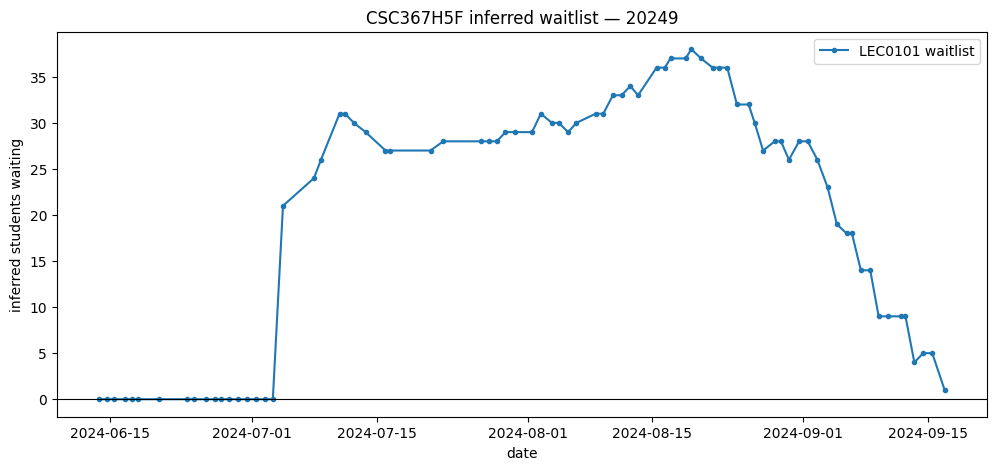

In [5]:
AUDIT_SESSION = '20249'
AUDIT_COURSE = 'CSC367H5F'

audit = reconstruct_course(AUDIT_SESSION, AUDIT_COURSE)
display(audit[['observed_at', 'meeting', 'capacity', 'demand', 'waitlist', 'days_to_deadline']].tail(20))

fig, ax = plt.subplots(figsize=(12, 5))
for meeting, group in audit.groupby('meeting'):
    ax.plot(group['observed_at'], group['waitlist'], marker='.', label=f'{meeting} waitlist')
ax.axhline(0, color='black', linewidth=0.8)
ax.set(title=f'{AUDIT_COURSE} inferred waitlist — {AUDIT_SESSION}', ylabel='inferred students waiting', xlabel='date')
ax.legend()
plt.show()

## 4. Manufacture position-level labels

A row is created for every position that actually existed (`position <= waitlist`); no artificial rank cap is applied. The legacy field `cleared_count` is cumulative observed downward waitlist movement from that snapshot through the deadline. Later increases do not erase earlier observed decreases. This is not a lower bound on individual advancement: departures behind a position can count, while churn hidden by offsetting arrivals between collector snapshots can be missed. Before sampling, each section-day has weight 1 divided across its positions. After sampling, weights are renormalized so every retained offering has total weight 1 and every retained day contributes equally within its offering.

In [6]:
FEATURE_COLUMNS = [
    'position', 'position_to_capacity', 'waitlist', 'waitlist_to_capacity',
    'capacity', 'days_to_deadline', 'movement_3d', 'movement_7d',
    'capacity_changed_7d', 'course_code', 'campus', 'term',
]


def make_position_examples(daily: pd.DataFrame, max_position: int | None = None) -> pd.DataFrame:
    if daily.empty:
        return pd.DataFrame()
    output = []
    for (_, meeting), section in daily.groupby(['course_code', 'meeting'], sort=False):
        section = section.sort_values('timestamp').copy()
        deadline_row = section.iloc[-1]
        deadline_gap_days = (deadline_row['deadline'] - deadline_row['timestamp']) / 86_400
        if deadline_gap_days > 3:
            continue  # Outcome is not observed close enough to closure.
        for _, snapshot in section.iterrows():
            waitlist = int(snapshot['waitlist'])
            if waitlist <= 0:
                continue
            upper = min(waitlist, max_position) if max_position else waitlist
            cleared_count = int(snapshot['observed_drops_to_deadline'])
            for position in range(1, upper + 1):
                row = snapshot.to_dict()
                row.update({
                    'position': position,
                    'position_to_capacity': position / snapshot['capacity'] if snapshot['capacity'] else np.nan,
                    'cleared_count': cleared_count,
                    'cleared': int(position <= cleared_count),
                    'sample_weight': 1 / upper,
                    'deadline_gap_days': deadline_gap_days,
                })
                output.append(row)
    return pd.DataFrame(output)


audit_examples = make_position_examples(audit)
audit_examples[['course_code', 'meeting', 'observed_at', 'position', 'waitlist', 'cleared_count', 'cleared']].tail(20)

,course_code,meeting,observed_at,position,waitlist,cleared_count,cleared
1568,CSC367H5F,LEC0101,2024-09-12 11:55:28-04:00,5,9,9,1
1569,CSC367H5F,LEC0101,2024-09-12 11:55:28-04:00,6,9,9,1
1570,CSC367H5F,LEC0101,2024-09-12 11:55:28-04:00,7,9,9,1
1571,CSC367H5F,LEC0101,2024-09-12 11:55:28-04:00,8,9,9,1
1572,CSC367H5F,LEC0101,2024-09-12 11:55:28-04:00,9,9,9,1
1573,CSC367H5F,LEC0101,2024-09-13 11:58:14-04:00,1,4,4,1
1574,CSC367H5F,LEC0101,2024-09-13 11:58:14-04:00,2,4,4,1
1575,CSC367H5F,LEC0101,2024-09-13 11:58:14-04:00,3,4,4,1
1576,CSC367H5F,LEC0101,2024-09-13 11:58:14-04:00,4,4,4,1
1577,CSC367H5F,LEC0101,2024-09-14 11:51:18-04:00,1,5,4,1


## 5. Load or build the canonical modelling cache

This is the only notebook that may reconstruct the full archive. It creates one deterministic sample of at most 300,000 position rows per completed session under `artifacts/feature-search-cache`.

Existing cache files are loaded and checked for their session, schema, row limit, labels, ranks, and weights. If every check passes, archive reconstruction is skipped. A missing or invalid session cache is rebuilt from the local archive. Notebooks 2–7 only read these validated files.


In [7]:
SESSION_ORDER = ['20229', '20235', '20239', '20245', '20249', '20255', '20259', '20265']


def engineer_cached_features(frame: pd.DataFrame) -> pd.DataFrame:
    frame = frame.copy()
    frame['meeting'] = frame['meeting'].fillna('UNKNOWN').astype(str)
    frame['lecture_number'] = frame['meeting'].str.extract(r'(\d+)', expand=False).fillna('-1')
    frame['position_to_waitlist'] = frame['position'] / frame['waitlist'].replace(0, np.nan)
    frame['days_squared'] = frame['days_to_deadline'] ** 2
    frame['log_waitlist'] = np.log1p(frame['waitlist'])
    frame['movement_velocity_7d'] = frame['movement_7d'] / 7
    parts = frame['course_code'].str.extract(r'^([A-Z]+)(\d)(\d{2})')
    frame['department'] = parts[0].fillna('UNKNOWN')
    frame['course_level'] = parts[1].fillna('UNKNOWN')
    frame['department_level'] = frame['department'] + frame['course_level']
    frame['course_number'] = (parts[0] + parts[1] + parts[2]).fillna('UNKNOWN')
    frame['days_rounded'] = frame['days_to_deadline'].round().astype('int16')
    frame['offering_id'] = frame['session'].astype(str) + ':' + frame['course_code'] + ':' + frame['meeting']
    floats = frame.select_dtypes(include=['float64']).columns
    frame[floats] = frame[floats].astype('float32')
    return frame


REQUIRED_CACHE_COLUMNS = {
    'session', 'course_code', 'meeting', 'offering_id', 'campus', 'term',
    'department', 'course_level', 'department_level', 'course_number',
    'cleared', 'model_weight', 'position', 'position_to_capacity',
    'waitlist', 'waitlist_to_capacity', 'capacity', 'days_to_deadline',
    'days_rounded', 'movement_3d', 'movement_7d', 'capacity_changed_7d',
    'lecture_number', 'position_to_waitlist', 'days_squared',
    'log_waitlist', 'movement_velocity_7d',
}


def validate_session_cache(frame: pd.DataFrame, session: str) -> list[str]:
    problems = []
    missing = REQUIRED_CACHE_COLUMNS.difference(frame.columns)
    if missing:
        problems.append('missing columns: ' + ', '.join(sorted(missing)))
        return problems
    if frame.empty:
        problems.append('contains no rows')
    if len(frame) > ROWS_PER_SESSION:
        problems.append(f'has {len(frame):,} rows, above the {ROWS_PER_SESSION:,} limit')
    if set(frame['session'].astype(str).unique()) != {session}:
        problems.append('contains rows from another session')
    if not frame['cleared'].isin([0, 1]).all():
        problems.append('contains invalid clearance labels')
    if not frame['position'].le(frame['waitlist']).all():
        problems.append('contains ranks above the observed waitlist')
    weights = frame['model_weight'].to_numpy(dtype=float)
    if not np.isfinite(weights).all() or not (weights > 0).all():
        problems.append('contains non-finite or non-positive model weights')
    offering_weight = frame.groupby('offering_id', observed=True)['model_weight'].sum().to_numpy()
    if not np.allclose(offering_weight, 1.0, rtol=1e-6, atol=1e-9):
        problems.append('does not give every retained offering total weight 1')
    return problems


def build_session_cache(session: str) -> pd.DataFrame:
    cache_path = CACHE_ROOT / f'{session}-{ROWS_PER_SESSION}-v{CACHE_VERSION}.pkl'
    if cache_path.exists():
        try:
            original = pd.read_pickle(cache_path)
            needs_upgrade = not REQUIRED_CACHE_COLUMNS.issubset(original.columns)
            cached = engineer_cached_features(original)
            problems = validate_session_cache(cached, session)
        except Exception as exc:
            cached = None
            needs_upgrade = False
            problems = [f'unreadable cache: {exc!r}']
        if not problems:
            print(f'{session}: valid cache found, skipping reconstruction', flush=True)
            if needs_upgrade:
                cached.to_pickle(cache_path)
            return cached
        problems_text = '; '.join(problems)
        print(f'{session}: invalid cache ({problems_text}), rebuilding', flush=True)
    if not DATA_ROOT.exists():
        raise FileNotFoundError(f'Missing local archive required to rebuild {session}: {DATA_ROOT}')
    print(f'{session}: reconstructing archive', flush=True)
    frames, failures = [], []
    paths = sorted(path for path in (DATA_ROOT / session).glob('*.json') if not path.name.startswith(('AA','aa')) and path.name != 'constants.json')
    for file_number, path in enumerate(paths, start=1):
        try:
            course = read_json(path)
            daily = reconstruct_course(session, course['code'])
            if not daily.empty:
                daily = daily[daily['meeting'].astype(str).str.startswith('LEC')]
            labelled = make_position_examples(daily)
            if not labelled.empty:
                frames.append(labelled)
        except Exception as exc:
            failures.append((path.name, repr(exc)))
        if file_number % 1000 == 0:
            print(f'  {file_number:,}/{len(paths):,} files', flush=True)
    if failures:
        raise RuntimeError(f'{session} reconstruction failures: {failures[:10]}')
    full = pd.concat(frames, ignore_index=True)
    full['offering_id'] = full['session'] + ':' + full['course_code'] + ':' + full['meeting']
    sampled = full.sample(n=min(ROWS_PER_SESSION, len(full)), random_state=RANDOM_STATE).copy()
    # Restore the intended weighting after row sampling. Each retained day has
    # equal weight within its lecture offering, and every retained offering has
    # total weight 1 regardless of queue size or sampled-row count.
    retained_day_mass = sampled.groupby(
        ['offering_id', 'calendar_day'], observed=True,
    )['sample_weight'].transform('sum')
    retained_days = sampled.groupby('offering_id', observed=True)['calendar_day'].transform('nunique')
    sampled['model_weight'] = sampled['sample_weight'] / retained_day_mass / retained_days
    cached = engineer_cached_features(sampled).reset_index(drop=True)
    keep = ['session','course_code','meeting','offering_id','campus','term','department','course_level','department_level','course_number','cleared','model_weight','position','position_to_capacity','waitlist','waitlist_to_capacity','capacity','days_to_deadline','days_rounded','movement_3d','movement_7d','capacity_changed_7d','lecture_number','position_to_waitlist','days_squared','log_waitlist','movement_velocity_7d']
    cached = cached[keep]
    cached.to_pickle(cache_path)
    print(f'{session}: cached {len(cached):,} of {len(full):,} rows', flush=True)
    del full, sampled, frames
    gc.collect()
    return cached


cache_workers = max(1, min(int(os.environ.get('ORACLE_CACHE_WORKERS', '23')), len(SESSION_ORDER)))
print(f'Building session caches with {cache_workers} worker process(es)', flush=True)
if cache_workers == 1:
    built_caches = [build_session_cache(session) for session in SESSION_ORDER]
else:
    built_caches = Parallel(
        n_jobs=cache_workers, backend='loky', batch_size=1, pre_dispatch=cache_workers, verbose=10,
    )(delayed(build_session_cache)(session) for session in SESSION_ORDER)
session_samples = dict(zip(SESSION_ORDER, built_caches))
del built_caches
print(f"Cached {sum(map(len, session_samples.values())):,} modelling rows")


Building session caches with 8 worker process(es)


[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.


20235: reconstructing archive
20229: reconstructing archive
20239: reconstructing archive
20249: reconstructing archive
20245: reconstructing archive
20255: reconstructing archive
20265: reconstructing archive
20259: reconstructing archive


  1,000/1,548 files


  1,000/1,591 files


...

[Parallel(n_jobs=8)]: Done   6 out of   8 | elapsed:  6.2min remaining:  2.1min


20259: cached 300,000 of 5,387,735 rows


20229: cached 300,000 of 5,081,167 rows


Cached 2,383,644 modelling rows


[Parallel(n_jobs=8)]: Done   8 out of   8 | elapsed:  6.6min finished


## 6. Cache integrity and leakage checks

Failures here block modelling. Current-session rows and target-derived fields must be absent from model inputs, ranks must have existed in their queues, and every cached session must satisfy the same schema contract.


In [8]:
examples = pd.concat(session_samples.values(), ignore_index=True)
assert not examples.empty
assert '20269' not in set(examples['session'].astype(str))
assert examples['position'].le(examples['waitlist']).all()
assert examples['cleared'].isin([0, 1]).all()
assert examples['days_to_deadline'].ge(0).all()
assert not {'cleared', 'cleared_count', 'observed_drops_to_deadline', 'deadline_gap_days'}.intersection(FEATURE_COLUMNS)
for session, frame in session_samples.items():
    assert not validate_session_cache(frame, session)

summary = pd.DataFrame({
    'rows': examples.groupby('session').size(),
    'courses': examples.groupby('session')['course_code'].nunique(),
    'weighted_clear_rate': examples.groupby('session').apply(
        lambda group: np.average(group['cleared'], weights=group['model_weight']),
        include_groups=False,
    ),
    'median_waitlist': examples.groupby('session')['waitlist'].median(),
    'median_days_to_deadline': examples.groupby('session')['days_to_deadline'].median(),
})
summary


,rows,courses,weighted_clear_rate,median_waitlist,median_days_to_deadline
session,,,,,
20229,300000,2722,0.887758,35.0,72.826530
20235,283644,403,0.933825,30.0,37.392105
20239,300000,3033,0.889714,37.0,90.191399
20245,300000,500,0.925682,28.0,37.473251
20249,300000,3217,0.874565,36.0,67.170601
20255,300000,575,0.907619,26.0,36.191933
20259,300000,3230,0.888172,32.0,78.763451
20265,300000,542,0.899452,30.0,39.355461


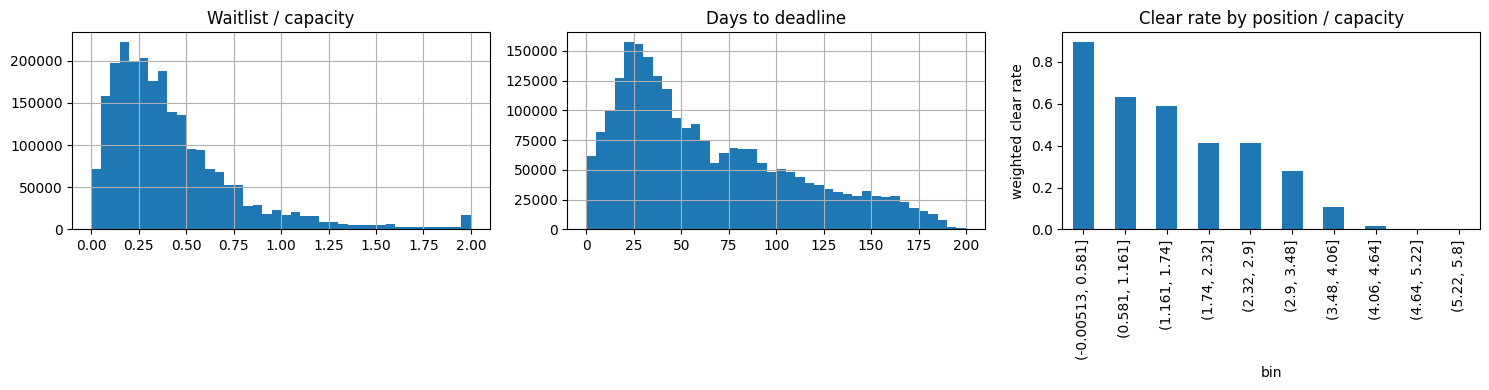

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
examples['waitlist_to_capacity'].clip(upper=2).hist(bins=40, ax=axes[0])
axes[0].set_title('Waitlist / capacity')
examples['days_to_deadline'].clip(upper=200).hist(bins=40, ax=axes[1])
axes[1].set_title('Days to deadline')
examples.groupby(pd.cut(examples['position_to_capacity'], bins=10), observed=True).apply(
    lambda group: np.average(group['cleared'], weights=group['model_weight']),
    include_groups=False,
).plot.bar(ax=axes[2])
axes[2].set(title='Clear rate by position / capacity', ylabel='weighted clear rate', xlabel='bin')
plt.tight_layout()
plt.show()

## 7. Findings

### Completed cache validation

- All eight completed-session cache files passed the schema and integrity checks.
- All eight sessions were reconstructed into cache version 5.
- The canonical cache contains **2,383,644 position rows**. Seven sessions contain 300,000 rows and Summer 2023 contains all 283,644 available rows.
- The incomplete `20269` session is excluded.
- Position examples cover every observed rank before deterministic session-level sampling. There is no artificial rank-100 ceiling.
- Cached course coverage ranges from 403 Summer courses to 3,230 Fall/Winter courses per session.

### Cached distributions

- Weighted target rates range from **87.5% to 93.4%** across sessions.
- Median inferred waitlists range from **26 to 37 students**.
- Summer observations have roughly **36?39 median days** before the applicable waitlist deadline.
- Fall/Winter observations have roughly **67?90 median days** remaining.
- These session shifts support chronological validation rather than a random train/test split.

### Reconstruction contract

- Waitlist size is inferred as demand above lecture capacity at each collector snapshot.
- The legacy `cleared` label means that cumulative observed downward queue movement reached the rank by the applicable waitlist deadline. It is not a verified admission.
- Capacity changes use the upstream `time` and `newCapacity` fields.
- Summer first and second subsessions use the archive's `fallWaitlistClosed` and `winterWaitlistClosed` fields.
- Unix timestamps are converted to Toronto time before calendar-day aggregation.

### Limitation

The label measures aggregate movement between collector snapshots, not individual student events. Departures behind the rank can be counted, while movement completely offset by new students joining between snapshots can be missed. It can therefore differ from actual student advancement in either direction.

**Decision:** use these validated cache files as the sole input to Notebooks 2?7.
